# OIL PRICE PREDICTION OF INDIA

#### Library import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Dataset load

In [2]:
df = pd.read_csv(r'D:\Dataset Practice\oil_price_india_prediction.csv')
df

,Year,Month,Brent_Oil_Price(US/b),WTI_Oil_Price(US/b),USD_INR,OPEC_Production(mb/d),Global_Oil_Demand(mb/d),Global_Conflict,Oil_Price_India(INR/b)
0,2003,12,29.81,32.13,45.5300,28.330620,79.840444,1,1425.111765
1,2004,1,31.28,34.31,45.0160,27.983461,79.953111,1,1478.505504
2,2004,2,30.86,34.69,45.1960,27.976877,80.065778,1,1464.485988
3,2004,3,33.63,36.74,43.3340,28.527540,80.178444,1,1530.188541
4,2004,4,33.59,36.75,44.2840,28.052807,80.291111,1,1561.874538
...,...,...,...,...,...,...,...,...,...
263,2025,11,63.80,60.06,89.3437,30.687027,109.471778,1,5985.134463
264,2025,12,62.54,57.97,89.7694,30.852614,109.584444,1,5894.887190
265,2026,1,66.60,60.04,91.6823,31.018200,109.697111,1,6411.343239
266,2026,2,70.89,64.51,91.0074,31.183787,109.809778,1,6774.090315


# Preprocessing

In [3]:
# Date and Month integration
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))

In [4]:
# conflict(1) and non-conflict(0) 
df['Global_Conflict'] = 0

conflicts = [
('2003-03','2004-06'),
('2008-08','2008-12'),
('2011-02','2011-10'),
('2014-02','2015-02'),
('2022-02','2026-03')
]

for start,end in conflicts:
    df.loc[(df['Date']>=start) & (df['Date']<=end),'Global_Conflict'] = 1

In [5]:
# Brent price * usd_inr = Oil price of india
df['Oil_Price_India(INR/b)'] = df['Brent_Oil_Price(US/b)'] * df['USD_INR']

In [6]:
# if Global_conflict == 1, price*=1.05
df.loc[df['Global_Conflict'] == 1, 'Oil_Price_India(INR/b)'] *= 1.05

In [7]:
df.head(10)

,Year,Month,Brent_Oil_Price(US/b),WTI_Oil_Price(US/b),USD_INR,OPEC_Production(mb/d),Global_Oil_Demand(mb/d),Global_Conflict,Oil_Price_India(INR/b),Date
0,2003,12,29.81,32.13,45.530,28.330620,79.840444,1,1425.111765,2003-12-01
1,2004,1,31.28,34.31,45.016,27.983461,79.953111,1,1478.505504,2004-01-01
2,2004,2,30.86,34.69,45.196,27.976877,80.065778,1,1464.485988,2004-02-01
3,2004,3,33.63,36.74,43.334,28.527540,80.178444,1,1530.188541,2004-03-01
4,2004,4,33.59,36.75,44.284,28.052807,80.291111,1,1561.874538,2004-04-01
5,2004,5,37.57,40.28,45.290,28.622535,80.403778,1,1786.622565,2004-05-01
6,2004,6,35.18,38.03,45.888,29.628462,80.516444,1,1695.056832,2004-06-01
7,2004,7,38.22,40.78,46.251,29.905191,80.629111,0,1767.713220,2004-07-01
8,2004,8,42.74,44.90,46.274,29.603891,80.741778,0,1977.750760,2004-08-01
9,2004,9,43.20,45.94,45.809,30.028648,80.854444,0,1978.948800,2004-09-01


In [8]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Year                     268 non-null    int64         
 1   Month                    268 non-null    int64         
 2   Brent_Oil_Price(US/b)    268 non-null    float64       
 3   WTI_Oil_Price(US/b)      268 non-null    float64       
 4   USD_INR                  268 non-null    float64       
 5   OPEC_Production(mb/d)    268 non-null    float64       
 6   Global_Oil_Demand(mb/d)  268 non-null    float64       
 7   Global_Conflict          268 non-null    int64         
 8   Oil_Price_India(INR/b)   268 non-null    float64       
 9   Date                     268 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 21.1 KB


In [9]:
# Date got removed (No need anymore)
df = df.drop('Date',axis=1)

In [10]:
df.shape

(268, 9)

In [11]:
# Descriptive datas 
df.describe()

,Year,Month,Brent_Oil_Price(US/b),WTI_Oil_Price(US/b),USD_INR,OPEC_Production(mb/d),Global_Oil_Demand(mb/d),Global_Conflict,Oil_Price_India(INR/b)
count,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,2014.585821,6.470149,73.908582,69.942575,61.608504,29.723852,94.881444,0.313433,4624.595908
std,6.463098,3.482842,24.353448,21.401052,15.030767,1.570721,8.732696,0.464757,1867.829939
min,2003.000000,1.000000,18.380000,16.550000,39.174000,22.876219,79.840444,0.000000,1383.251230
25%,2009.000000,3.000000,56.457500,53.837500,46.090500,28.819533,87.360944,0.000000,3109.547763
50%,2015.000000,6.000000,71.380000,68.900000,63.144000,29.806920,94.881444,0.000000,4350.404608
75%,2020.000000,9.250000,90.682500,85.392500,73.609425,30.656288,102.401944,1.000000,6145.861320
max,2026.000000,12.000000,132.720000,133.880000,91.936200,32.921847,109.922444,1.000000,10165.690913


In [12]:
# Null values checking
df.isnull().sum()

Year                       0
Month                      0
Brent_Oil_Price(US/b)      0
WTI_Oil_Price(US/b)        0
USD_INR                    0
OPEC_Production(mb/d)      0
Global_Oil_Demand(mb/d)    0
Global_Conflict            0
Oil_Price_India(INR/b)     0
dtype: int64

In [13]:
df.columns

Index(['Year', 'Month', 'Brent_Oil_Price(US/b)', 'WTI_Oil_Price(US/b)',
       'USD_INR', 'OPEC_Production(mb/d)', 'Global_Oil_Demand(mb/d)',
       'Global_Conflict', 'Oil_Price_India(INR/b)'],
      dtype='object')

<Axes: >

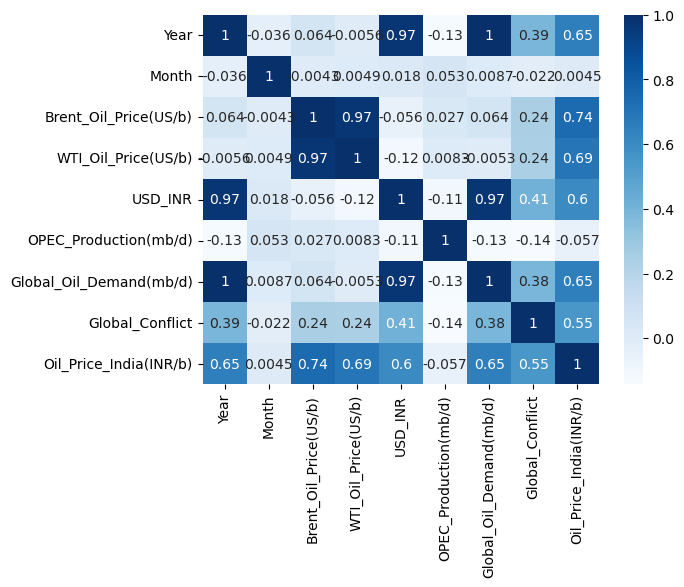

In [14]:
# Correlation Checking
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues')

# Analysis

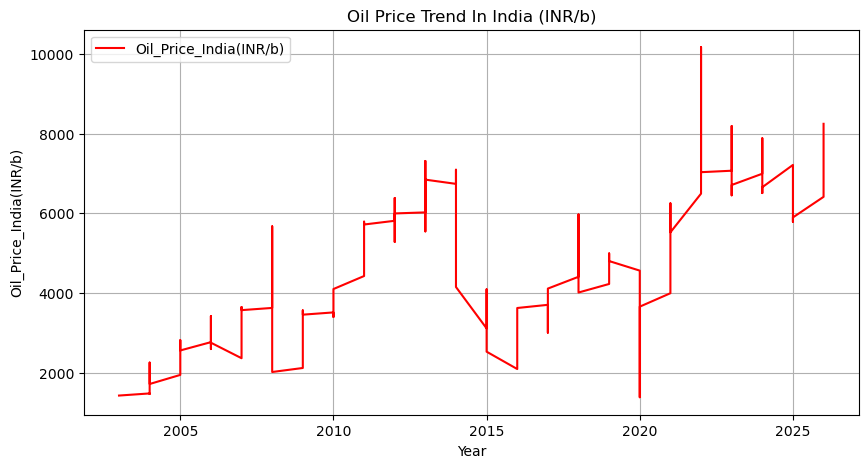

In [15]:
# .plot, oil price trend over time in India

plt.figure(figsize=(10,5))
plt.plot(df['Year'],df['Oil_Price_India(INR/b)'],label='Oil_Price_India(INR/b)',color='red')
plt.title('Oil Price Trend In India (INR/b)')
plt.xlabel('Year')
plt.ylabel('Oil_Price_India(INR/b)')
plt.legend()
plt.grid(True)
plt.show()

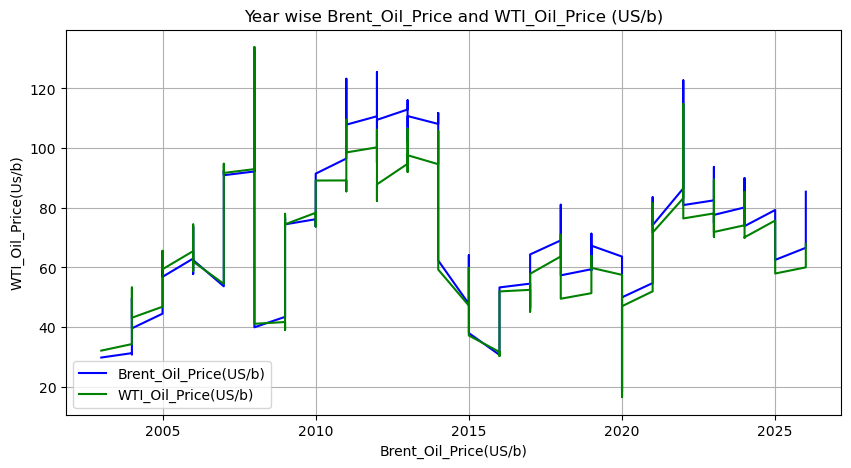

In [16]:
# Year wise Brent_Oil_Price and WTI_Oil_Price
plt.figure(figsize=(10,5))
plt.plot(df['Year'],df['Brent_Oil_Price(US/b)'],label='Brent_Oil_Price(US/b)',color='blue')
plt.plot(df['Year'],df['WTI_Oil_Price(US/b)'],label='WTI_Oil_Price(US/b)',color='green')
plt.title('Year wise Brent_Oil_Price and WTI_Oil_Price (US/b)')
plt.legend()
plt.grid(True)
plt.xlabel('Brent_Oil_Price(US/b)')
plt.ylabel('WTI_Oil_Price(Us/b)')
plt.show()

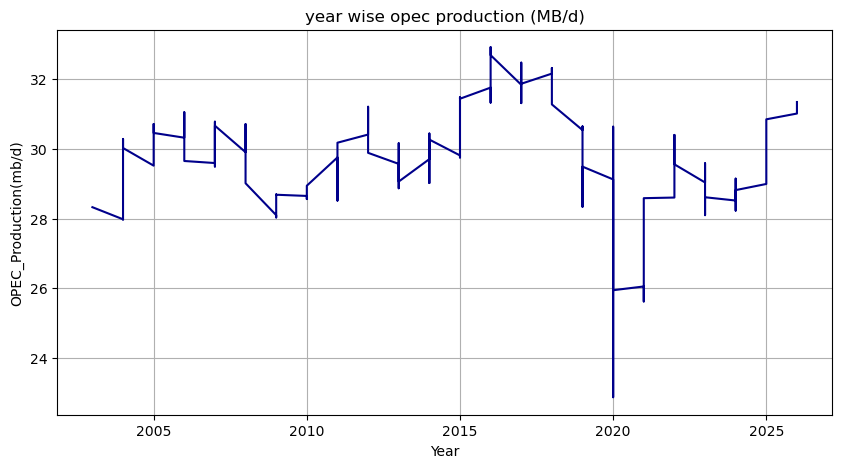

In [17]:
# year wise opec production
plt.figure(figsize=(10,5))
plt.plot(df['Year'],df['OPEC_Production(mb/d)'],label='OPEC_Production(mb/d)',color='darkblue')
plt.title('year wise opec production (MB/d)')
plt.xlabel('Year')
plt.ylabel('OPEC_Production(mb/d)')
plt.grid(True)
plt.show()

<Figure size 800x400 with 0 Axes>

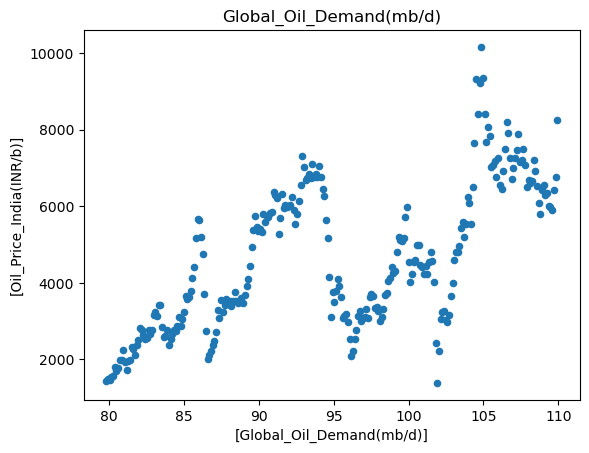

In [18]:
# Global_Oil_Demand(mb/d) and Oil_Price_India(INR/b)
plt.figure(figsize=(8,4))
df.plot.scatter(x=['Global_Oil_Demand(mb/d)'],y=['Oil_Price_India(INR/b)'])
plt.title('Global_Oil_Demand(mb/d)')
plt.show()

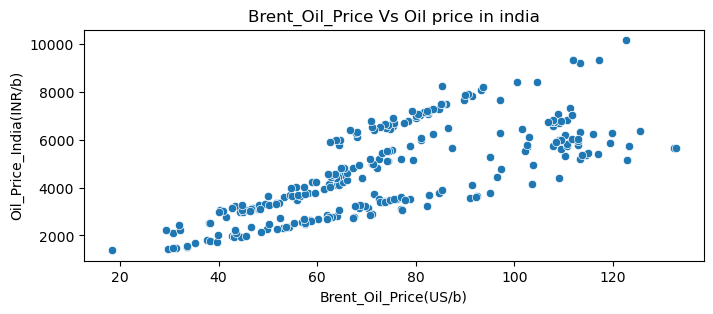

In [19]:
# Brent_Oil_Price Vs Oil price in india
plt.figure(figsize=(8,3))
sns.scatterplot(x=df['Brent_Oil_Price(US/b)'],y=df['Oil_Price_India(INR/b)'])
plt.title('Brent_Oil_Price Vs Oil price in india')
plt.show()

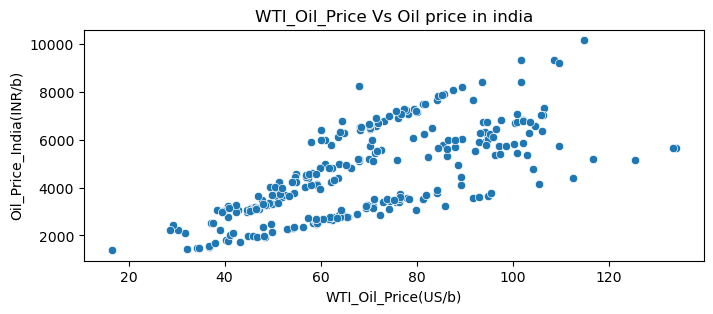

In [20]:
# WTI_Oil_Price Vs Oil price in india
plt.figure(figsize=(8,3))
sns.scatterplot(x=df['WTI_Oil_Price(US/b)'],y=df['Oil_Price_India(INR/b)'])
plt.title('WTI_Oil_Price Vs Oil price in india')
plt.show()

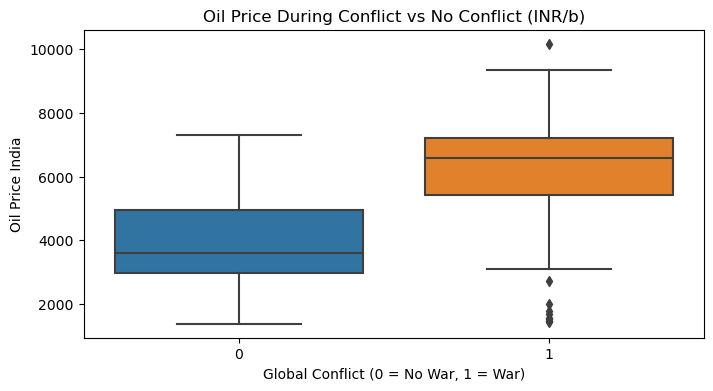

In [21]:
# box, Global_Conflict and Oil_Price_India
plt.figure(figsize=(8,4))
sns.boxplot(x='Global_Conflict', y='Oil_Price_India(INR/b)', data=df)
plt.title("Oil Price During Conflict vs No Conflict (INR/b)")
plt.xlabel("Global Conflict (0 = No War, 1 = War)")
plt.ylabel("Oil Price India")
plt.show()

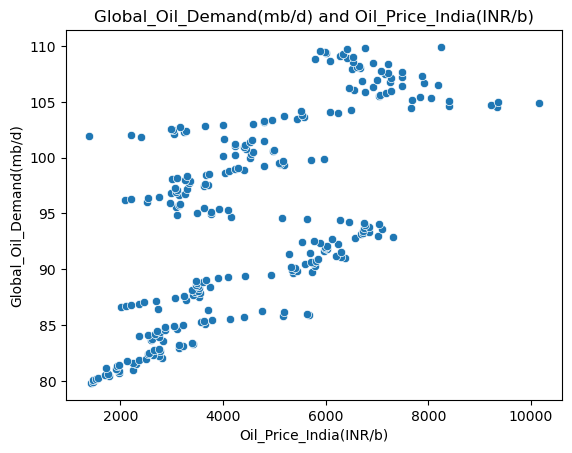

In [22]:
# scatterplot, Global_Oil_Demand(mb/d) and Oil_Price_India

sns.scatterplot(x=df['Oil_Price_India(INR/b)'],y=df['Global_Oil_Demand(mb/d)'])
plt.title('Global_Oil_Demand(mb/d) and Oil_Price_India(INR/b)')
plt.show()

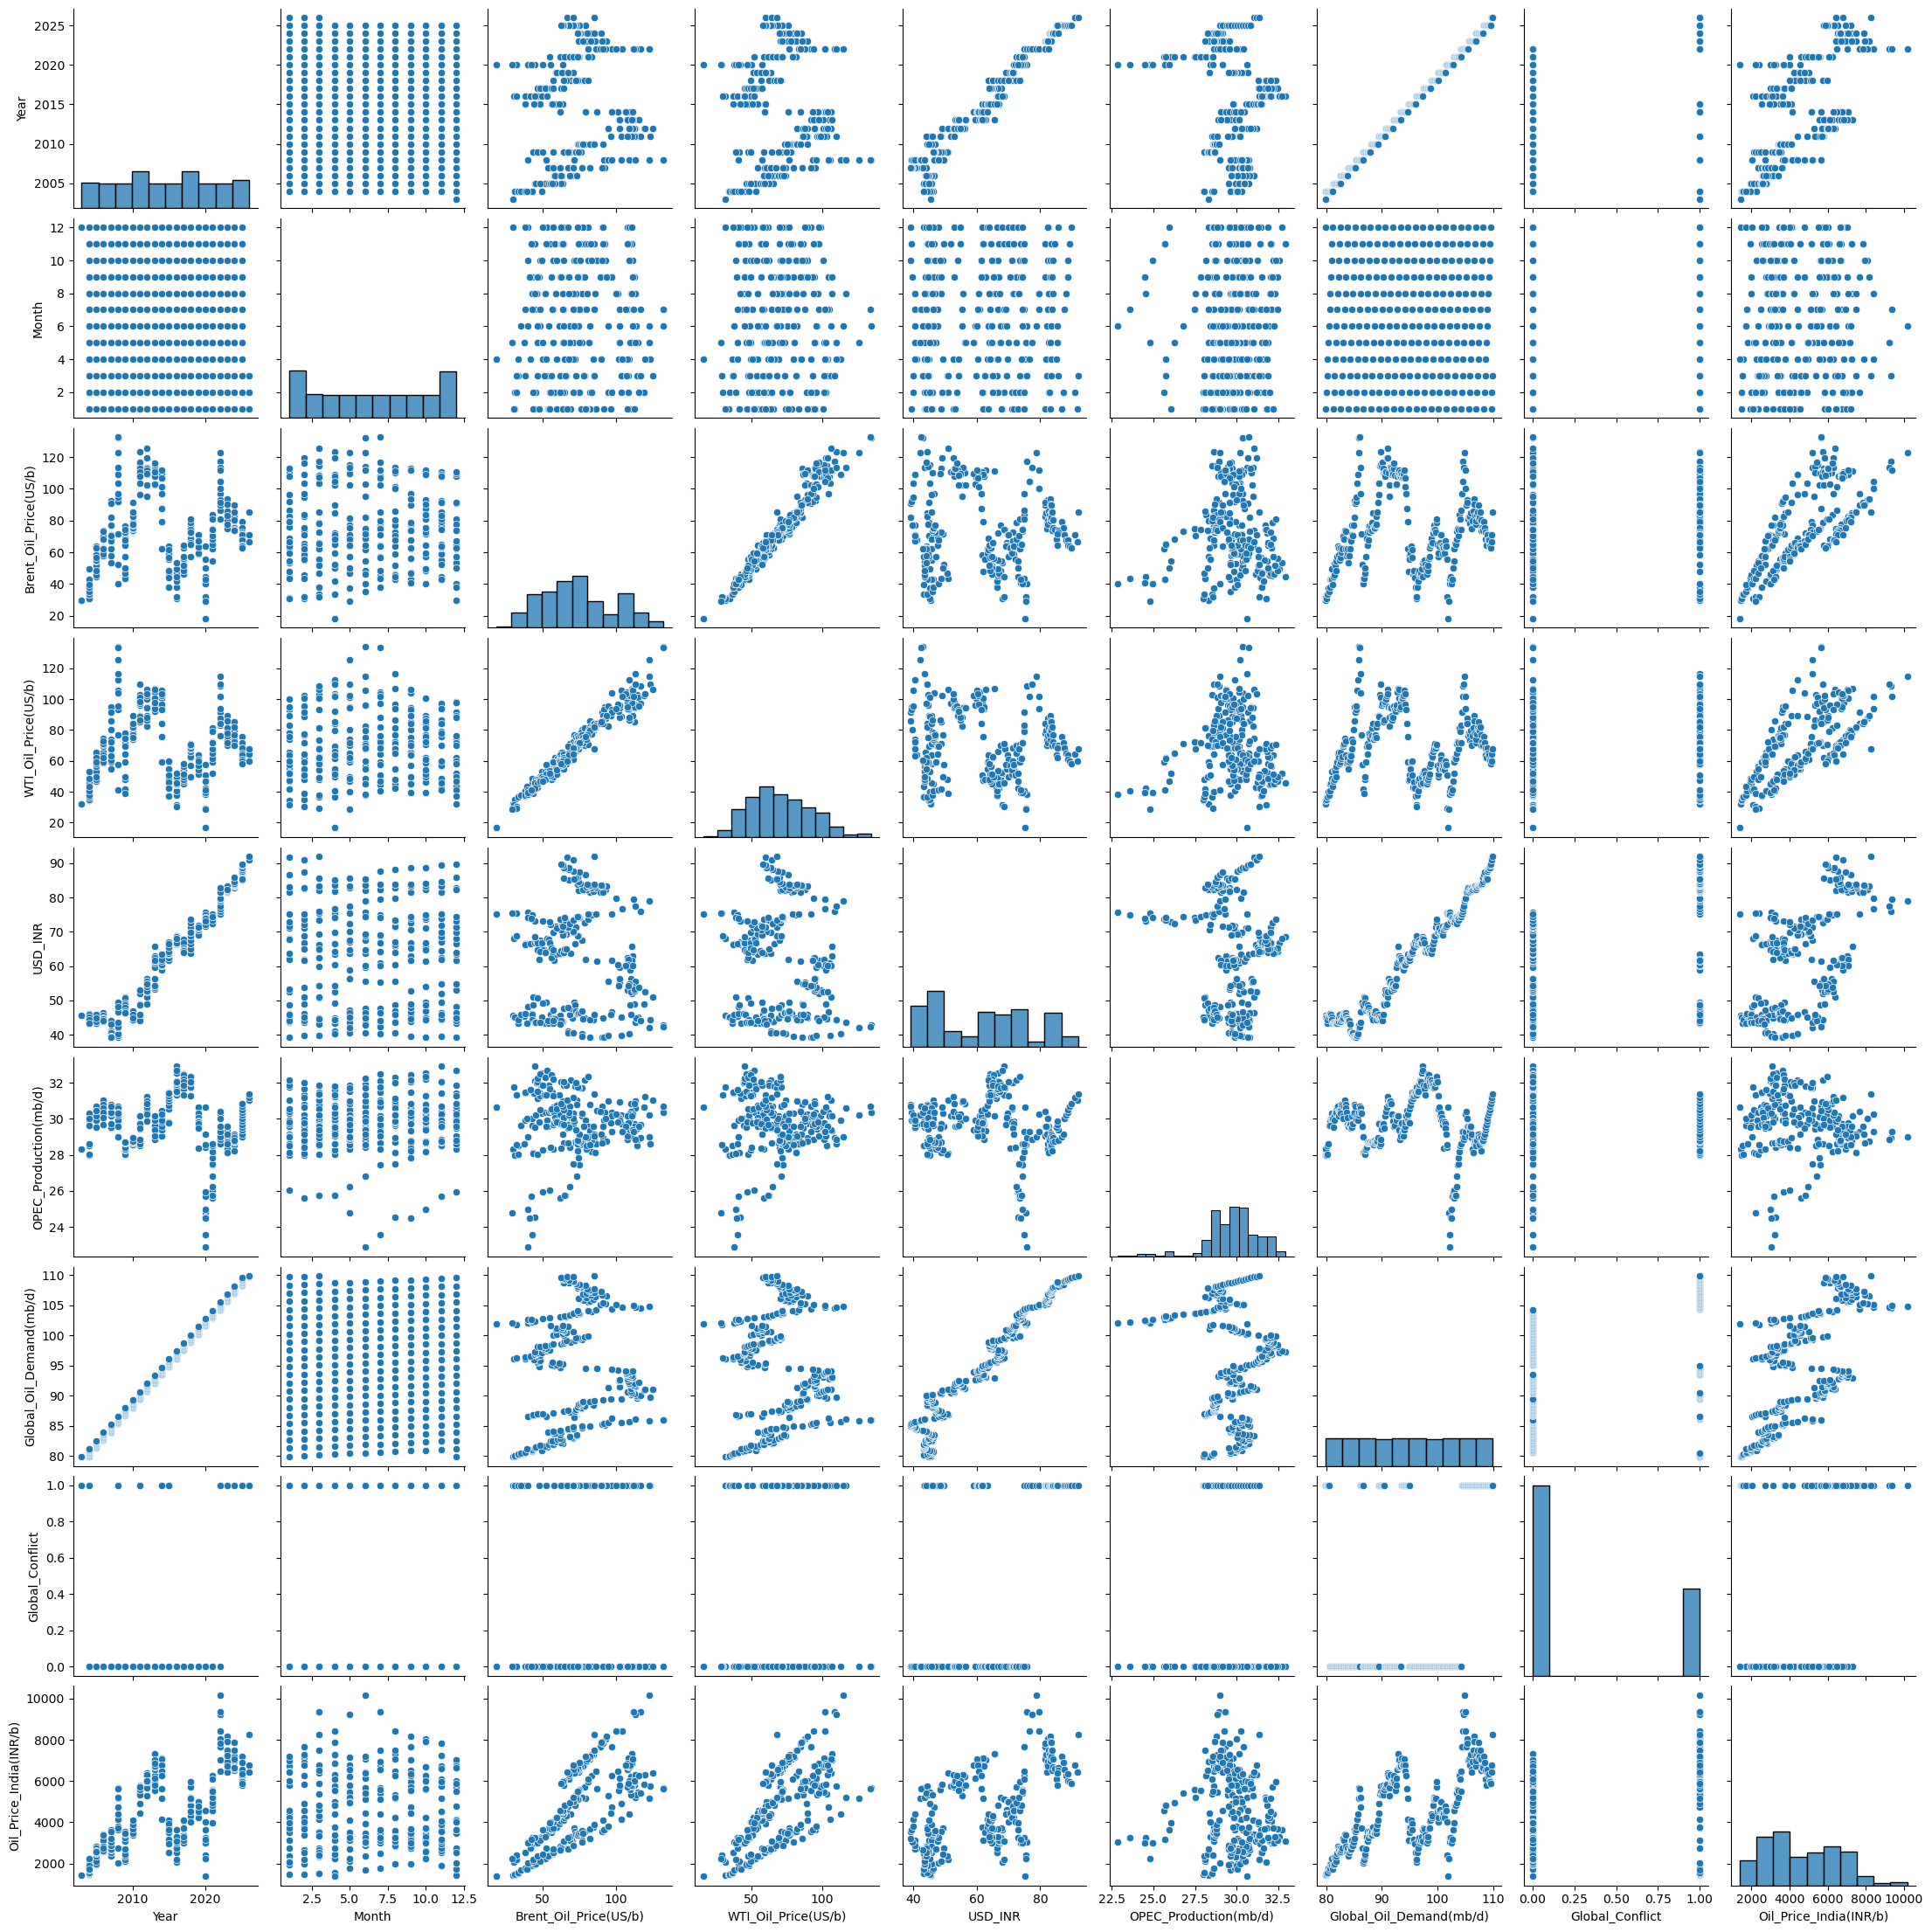

In [23]:
# pairplot
sns.pairplot(df)

# ML Pipeline

In [24]:
df.corr()

,Year,Month,Brent_Oil_Price(US/b),WTI_Oil_Price(US/b),USD_INR,OPEC_Production(mb/d),Global_Oil_Demand(mb/d),Global_Conflict,Oil_Price_India(INR/b)
Year,1.000000,-0.036241,0.063718,-0.005563,0.969109,-0.133612,0.998991,0.385023,0.652792
Month,-0.036241,1.000000,-0.004294,0.004923,0.018241,0.053200,0.008671,-0.021964,0.004508
Brent_Oil_Price(US/b),0.063718,-0.004294,1.000000,0.974736,-0.055875,0.027197,0.063565,0.243205,0.741089
WTI_Oil_Price(US/b),-0.005563,0.004923,0.974736,1.000000,-0.116820,0.008311,-0.005345,0.237965,0.692049
USD_INR,0.969109,0.018241,-0.055875,-0.116820,1.000000,-0.106834,0.970529,0.413523,0.600933
OPEC_Production(mb/d),-0.133612,0.053200,0.027197,0.008311,-0.106834,1.000000,-0.131304,-0.142715,-0.057088
Global_Oil_Demand(mb/d),0.998991,0.008671,0.063565,-0.005345,0.970529,-0.131304,1.000000,0.384275,0.653399
Global_Conflict,0.385023,-0.021964,0.243205,0.237965,0.413523,-0.142715,0.384275,1.000000,0.547595
Oil_Price_India(INR/b),0.652792,0.004508,0.741089,0.692049,0.600933,-0.057088,0.653399,0.547595,1.000000


In [25]:
df.columns

Index(['Year', 'Month', 'Brent_Oil_Price(US/b)', 'WTI_Oil_Price(US/b)',
       'USD_INR', 'OPEC_Production(mb/d)', 'Global_Oil_Demand(mb/d)',
       'Global_Conflict', 'Oil_Price_India(INR/b)'],
      dtype='object')

In [26]:
# Low impact with the output label so get removed
df1 = df.drop(['Month','WTI_Oil_Price(US/b)','OPEC_Production(mb/d)'],axis=1)

In [27]:
df1

,Year,Brent_Oil_Price(US/b),USD_INR,Global_Oil_Demand(mb/d),Global_Conflict,Oil_Price_India(INR/b)
0,2003,29.81,45.5300,79.840444,1,1425.111765
1,2004,31.28,45.0160,79.953111,1,1478.505504
2,2004,30.86,45.1960,80.065778,1,1464.485988
3,2004,33.63,43.3340,80.178444,1,1530.188541
4,2004,33.59,44.2840,80.291111,1,1561.874538
...,...,...,...,...,...,...
263,2025,63.80,89.3437,109.471778,1,5985.134463
264,2025,62.54,89.7694,109.584444,1,5894.887190
265,2026,66.60,91.6823,109.697111,1,6411.343239
266,2026,70.89,91.0074,109.809778,1,6774.090315


In [28]:
# convert data to numeric
# df1 = df1.apply(pd.to_numeric, errors='coerce')

In [29]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     268 non-null    int64  
 1   Brent_Oil_Price(US/b)    268 non-null    float64
 2   USD_INR                  268 non-null    float64
 3   Global_Oil_Demand(mb/d)  268 non-null    float64
 4   Global_Conflict          268 non-null    int64  
 5   Oil_Price_India(INR/b)   268 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 12.7 KB


#### ip and op

In [30]:
# ip/op
ip = df1.drop('Oil_Price_India(INR/b)',axis=1)
op = df1['Oil_Price_India(INR/b)']

#### train_test_split

In [31]:
# train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ip,op,test_size=0.2)

#### StandardScaler

In [32]:
# StandardScaler
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Model 1: Linear Regression

In [33]:
# Model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [34]:
#prediction
lr_pred = lr.predict(x_test)
lr_pred

array([5730.11856312, 2143.52681515, 3393.22334409, 6540.75332001,
       3120.91370631, 3505.45309112, 4769.52776634, 2962.41244446,
       3293.67914107, 5220.81199057, 6638.49585825, 3804.3627423 ,
       2555.52341216, 6342.81737393, 3758.24957216, 3543.64390913,
       5949.36002621, 5802.7211246 , 4420.24791149, 2567.33428979,
       6615.7965893 , 3202.879809  , 4318.40946648, 6526.89550783,
       7424.04737041, 6963.50459372, 7129.24785115, 4072.04854196,
       3299.95110525, 3889.7955468 , 3719.54365934, 2180.71682724,
       4544.16963585, 2035.81824404, 2755.35683242, 3247.35952705,
       5284.37174808, 3233.18759675, 4141.83191558, 1767.4653903 ,
       2233.83660158, 3673.24043535, 5312.29643056, 5985.25232719,
       5798.36437141, 4429.8097323 , 3161.13320472, 7278.7633807 ,
       6082.5342657 , 3464.12578181, 2384.5634647 , 2738.45953017,
       6837.29483761, 2010.67154063])

In [35]:
# metrics
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2_lr = r2_score(y_test,lr_pred)
# mse_lr = mean_squared_error(y_test,lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test,lr_pred))
mae_lr = mean_absolute_error(y_test,lr_pred)
print('r2 score:',r2_lr)
print('rmse score:',rmse_lr)
print('mae score:',mae_lr)

r2 score: 0.9780615859858108
rmse score: 238.47206650980854
mae score: 190.93987106182783


In [36]:
# Dataframe
dframe = pd.DataFrame({'Predicted':lr_pred,'Actual data':y_test})
dframe.head(10)

,Predicted,Actual data
130,5730.118563,5639.641550
15,2143.526815,2315.691000
133,3393.223344,3109.827924
234,6540.753320,6449.649083
66,3120.913706,3279.626610
150,3505.453091,3252.822000
207,4769.527766,4804.057073
162,2962.412444,3004.085087
77,3293.679141,3520.890100
176,5220.811991,5179.004650


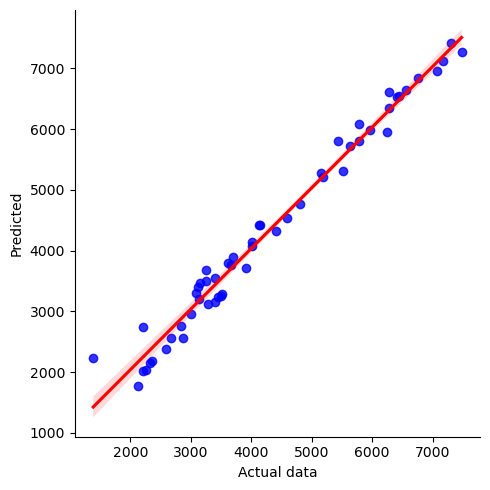

In [37]:
# plot
sns.lmplot(dframe,y='Predicted',x='Actual data',scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.show()

### Predicting Future Data of Oil Prices in India using Linear Regression

In [38]:
ip.tail(3)

,Year,Brent_Oil_Price(US/b),USD_INR,Global_Oil_Demand(mb/d),Global_Conflict
265,2026,66.60,91.6823,109.697111,1
266,2026,70.89,91.0074,109.809778,1
267,2026,85.40,91.9362,109.922444,1


In [39]:
op.tail(3)

265    6411.343239
266    6774.090315
267    8243.919054
Name: Oil_Price_India(INR/b), dtype: float64

In [40]:
# Future Data Prediction
future = pd.DataFrame({
'Year':[2026],
'Brent_Oil_Price(US/b)':[90],
'USD_INR':[92],
'Global_Oil_Demand(mb/d)':[110],
'Global_Conflict':[1]
})
f_scale = sc.transform(future)
prediction = lr.predict(f_scale)
print('Future oil price of India in INR:',prediction[0])

Future oil price of India in INR: 8367.064474545828


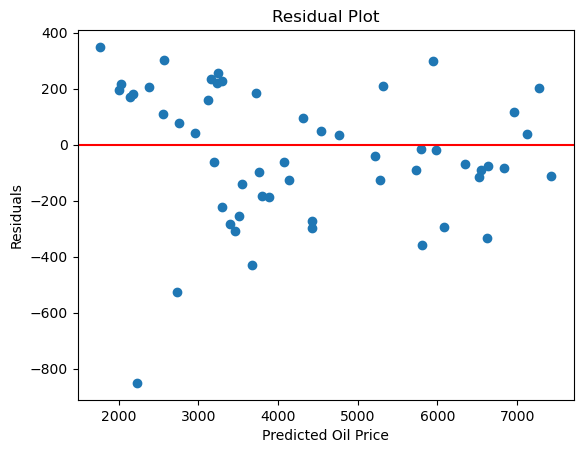

In [41]:
# Test spread of residuals of data
residuals_lr = y_test - lr_pred

plt.scatter(lr_pred, residuals_lr)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Oil Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [42]:
# Coefficient datas
coef = pd.DataFrame({
'Feature': ip.columns,
'Coefficient': lr.coef_
})
print(coef)

                   Feature  Coefficient
0                     Year   234.786158
1    Brent_Oil_Price(US/b)  1507.800527
2                  USD_INR  1864.128010
3  Global_Oil_Demand(mb/d)  -955.409932
4          Global_Conflict   189.881467


## Model 2: Ridge Algorithm

In [43]:
# Model
from sklearn.linear_model import Ridge
ri = Ridge(alpha=1.0)
ri.fit(x_train,y_train)

Ridge()

In [44]:
#prediction
ri_pred = ri.predict(x_test)
ri_pred

array([5751.661101  , 2078.04494914, 3440.08700121, 6539.76290596,
       3135.36674481, 3484.10815726, 4782.19635264, 3030.15884069,
       3351.46288078, 5180.56952559, 6517.91734144, 3814.32521773,
       2496.9606938 , 6336.69090256, 3743.94131522, 3472.15974558,
       5963.70964553, 5904.95294106, 4468.8150018 , 2643.80371032,
       6614.59025025, 3135.03746122, 4365.63980907, 6550.67911651,
       7219.32090557, 6976.27000883, 7071.08104068, 4118.25787831,
       3304.59553722, 3847.78557375, 3820.21547525, 2157.03197682,
       4548.06848323, 1983.94653615, 2725.75050054, 3322.33542126,
       5321.05268478, 3311.65053246, 4147.31757482, 1769.01162047,
       2267.56506698, 3692.13436744, 5366.428591  , 5906.69831023,
       5749.12913899, 4457.4497117 , 3203.12600511, 7263.07717221,
       6154.99034711, 3535.68082206, 2386.21358627, 2689.47430849,
       6793.18228414, 1982.53156031])

In [45]:
# metrics
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2_ri = r2_score(y_test,ri_pred)
# mse_ri = mean_squared_error(y_test,ri_pred)
rmse_ri = np.sqrt(mean_squared_error(y_test,ri_pred))
mae_ri = mean_absolute_error(y_test,ri_pred)
print('r2 score:',r2_ri)
print('rmse score:',rmse_ri)
print('mae score:',mae_ri)

r2 score: 0.9769792954479194
rmse score: 244.2835410122986
mae score: 190.0761618059976


In [46]:
# Dataframe
dframe = pd.DataFrame({'Predicted':ri_pred,'Actual data':y_test})
dframe.head(10)

,Predicted,Actual data
130,5751.661101,5639.641550
15,2078.044949,2315.691000
133,3440.087001,3109.827924
234,6539.762906,6449.649083
66,3135.366745,3279.626610
150,3484.108157,3252.822000
207,4782.196353,4804.057073
162,3030.158841,3004.085087
77,3351.462881,3520.890100
176,5180.569526,5179.004650


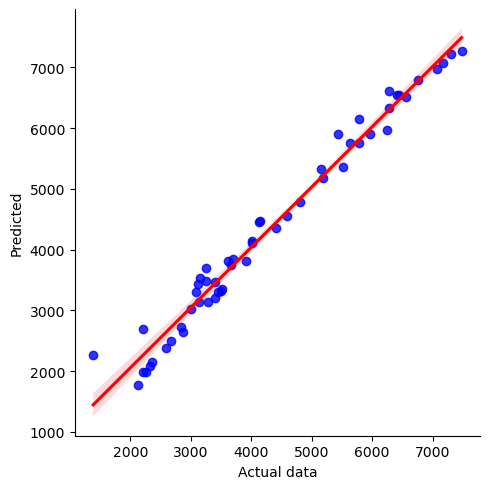

In [47]:
# plot
sns.lmplot(dframe,y='Predicted',x='Actual data',scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.show()

### Predicting Future Data of Oil Prices in India using Ridge Algorithm

In [48]:
ip.tail(3)

,Year,Brent_Oil_Price(US/b),USD_INR,Global_Oil_Demand(mb/d),Global_Conflict
265,2026,66.60,91.6823,109.697111,1
266,2026,70.89,91.0074,109.809778,1
267,2026,85.40,91.9362,109.922444,1


In [49]:
op.tail(3)

265    6411.343239
266    6774.090315
267    8243.919054
Name: Oil_Price_India(INR/b), dtype: float64

In [50]:
# Future Data Prediction
future = pd.DataFrame({
'Year':[2026],
'Brent_Oil_Price(US/b)':[90],
'USD_INR':[92],
'Global_Oil_Demand(mb/d)':[110],
'Global_Conflict':[1]
})
f_scale = sc.transform(future)
prediction = ri.predict(f_scale)
print('Future oil price of India in INR:',prediction[0])

Future oil price of India in INR: 8262.057673917943


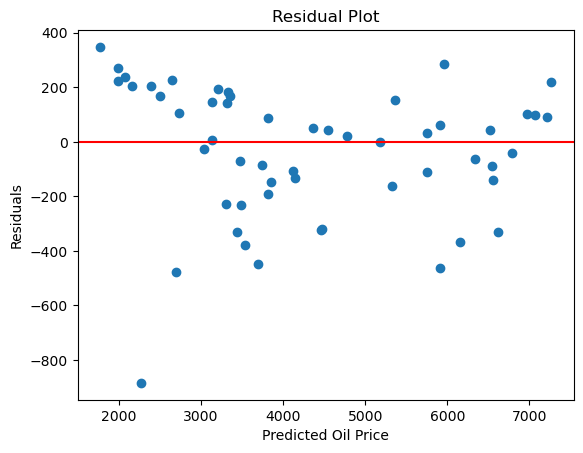

In [51]:
# Test spread of residuals of data 
residuals_ri = y_test - ri_pred

plt.scatter(ri_pred, residuals_ri)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Oil Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [52]:
# Coefficient checking
coef = pd.DataFrame({
'Feature': ip.columns,
'Coefficient': ri.coef_
})
print(coef)

                   Feature  Coefficient
0                     Year  -163.305750
1    Brent_Oil_Price(US/b)  1463.382321
2                  USD_INR  1593.013586
3  Global_Oil_Demand(mb/d)  -299.086169
4          Global_Conflict   214.492904


## Model 3: KNN Regressor

In [53]:
# for calculating the best n_neighbors

# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.metrics import r2_score
# for k in range(1,10):
#     knn = KNeighborsRegressor(n_neighbors=k)
#     knn.fit(x_train,y_train)
#     pred = knn.predict(x_test)
#     r2 = r2_score(y_test,pred)
#     print(k,r2)

In [54]:
# Model
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsRegressor()

In [55]:
#prediction
knn_pred = knn.predict(x_test)
knn_pred

array([6782.6106831 , 2413.70636   , 3079.1752069 , 6689.41563024,
       3344.26306   , 3124.2219758 , 4820.240901  , 3224.5364298 ,
       3520.299636  , 5180.6011422 , 6802.897056  , 3313.7853078 ,
       2706.861168  , 6782.6106831 , 3471.034467  , 3086.7446    ,
       5825.4945942 , 5407.011771  , 4684.1831757 , 2906.314372  ,
       6191.96538093, 3063.494836  , 4499.1329682 , 6547.65633228,
       6802.897056  , 7059.19479489, 7107.50032356, 4330.5608858 ,
       3124.2219758 , 3481.986625  , 3706.7229    , 2626.519508  ,
       4552.4121262 , 2352.756784  , 2713.721298  , 3520.299636  ,
       6181.1709771 , 3498.14086   , 4069.02285   , 2626.519508  ,
       2737.2479852 , 3196.3673824 , 5341.5236782 , 5224.2145194 ,
       5845.380824  , 3806.900168  , 3513.387544  , 7398.28876878,
       5407.011771  , 3196.3673824 , 2644.59168   , 2596.565442  ,
       6900.9504018 , 2626.519508  ])

In [56]:
# metrics
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2_knn = r2_score(y_test,knn_pred)
# mse_knn = mean_squared_error(y_test,knn_pred)
rmse_knn = np.sqrt(mean_squared_error(y_test,knn_pred))
mae_knn = mean_absolute_error(y_test,knn_pred)
print('r2 score:',r2_knn)
print('rmse score:',rmse_knn)
print('mae score:',mae_knn)

r2 score: 0.9470767347323563
rmse score: 370.3891164687254
mae score: 237.87664464925922


In [57]:
# Dataframe
dframe = pd.DataFrame({'Predicted':knn_pred,'Actual data':y_test})
dframe.head(10)

,Predicted,Actual data
130,6782.610683,5639.641550
15,2413.706360,2315.691000
133,3079.175207,3109.827924
234,6689.415630,6449.649083
66,3344.263060,3279.626610
150,3124.221976,3252.822000
207,4820.240901,4804.057073
162,3224.536430,3004.085087
77,3520.299636,3520.890100
176,5180.601142,5179.004650


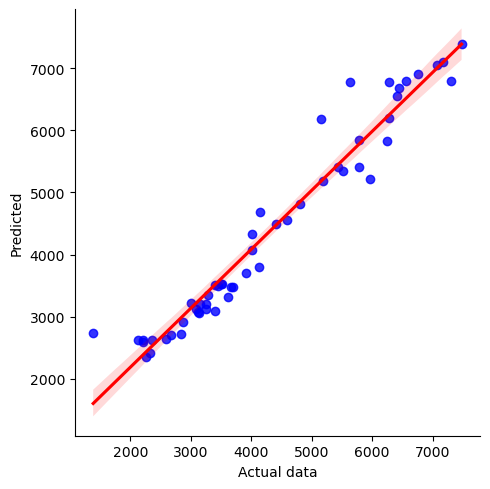

In [58]:
# plot
sns.lmplot(dframe,y='Predicted',x='Actual data',scatter_kws={'color':'blue'},line_kws={'color':'red'})
plt.show()

### Predicting Future Data of Oil Prices in India using KNN Regressor

In [59]:
ip.tail(3)

,Year,Brent_Oil_Price(US/b),USD_INR,Global_Oil_Demand(mb/d),Global_Conflict
265,2026,66.60,91.6823,109.697111,1
266,2026,70.89,91.0074,109.809778,1
267,2026,85.40,91.9362,109.922444,1


In [60]:
op.tail(3)

265    6411.343239
266    6774.090315
267    8243.919054
Name: Oil_Price_India(INR/b), dtype: float64

In [61]:
# Future Data Prediction
future = pd.DataFrame({
'Year':[2026],
'Brent_Oil_Price(US/b)':[90],
'USD_INR':[92],
'Global_Oil_Demand(mb/d)':[110],
'Global_Conflict':[1]
})
f_scale = sc.transform(future)
prediction = knn.predict(f_scale)
print('Future oil price of India in INR:',prediction[0])

Future oil price of India in INR: 7548.1929251400015


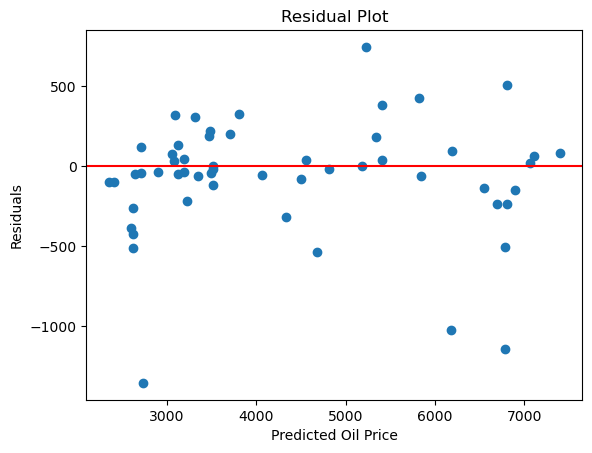

In [62]:
# Test spread of residuals of data
residuals_knn = y_test - knn_pred

plt.scatter(knn_pred, residuals_knn)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Oil Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [63]:
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(214, 5) (54, 5)
(214,) (54,)


# Conclusion

Linear Regression and Ridge Regression both performed well, achieving high R² scores with low RMSE and MAE, indicating that the dataset follows a largely linear pattern. While Linear Regression showed slightly better metrics, Ridge Regression provided more stability due to regularization, making it more reliable in handling feature relationships.

KNN Regression, although improved after scaling, showed higher error and more scattered residuals, indicating lower stability. It also produced less consistent future predictions compared to Linear and Ridge models.

Overall, Linear Regression offers strong performance, while Ridge Regression is a more robust and dependable choice. KNN is less suitable for this dataset due to its sensitivity to data distribution.

In [70]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'KNN'],
    'R2 Score': [0.9780, 0.9769, 0.9470],   # replace with your values
    'RMSE': [238, 244, 370],
    'MAE': [190, 190, 237],
    'Stability': ['Best', 'Good', 'Unstable']
})

results

,Model,R2 Score,RMSE,MAE,Stability
0,Linear,0.9780,238,190,Best
1,Ridge,0.9769,244,190,Good
2,KNN,0.9470,370,237,Unstable
